# Semantic Segmentation

## Problem definition

Classification outputs one label per image. Detection outputs a handful of boxes per image. Segmentation outputs one label per pixel.

to solve tasks can not be solved by putting a box around the object; they need **the exact silhouette.**

The architectural problem is simple to state and not simple to solve: you need the network to see **the global context of an image (what kind of scene is this) and the local pixel detail (exactly which pixel is road vs pavement) simultaneously.** A standard CNN compresses spatially to gain context, which throws away the detail. U-Net was the design that got both.

## Basic Concept

### Semantic vs instance vs panoptic

```mermaid
flowchart LR
    IN["Input image"] --> SEM["Semantic<br/>(pixel → class)"]
    IN --> INS["Instance<br/>(pixel → object id,<br/>only foreground classes)"]
    IN --> PAN["Panoptic<br/>(every pixel → class + id)"]

    style SEM fill:#dbeafe,stroke:#2563eb
    style INS fill:#fef3c7,stroke:#d97706
    style PAN fill:#dcfce7,stroke:#16a34a
```

### The U-Net shape

```mermaid
flowchart LR
    subgraph ENC["Encoder (contracting)"]
        E1["64<br/>H x W"] --> E2["128<br/>H/2 x W/2"]
        E2 --> E3["256<br/>H/4 x W/4"]
        E3 --> E4["512<br/>H/8 x W/8"]
    end
    subgraph BOT["Bottleneck"]
        B1["1024<br/>H/16 x W/16"]
    end
    subgraph DEC["Decoder (expanding)"]
        D4["512<br/>H/8 x W/8"] --> D3["256<br/>H/4 x W/4"]
        D3 --> D2["128<br/>H/2 x W/2"]
        D2 --> D1["64<br/>H x W"]
    end
    E4 --> B1 --> D4
    E1 -. skip .-> D1
    E2 -. skip .-> D2
    E3 -. skip .-> D3
    E4 -. skip .-> D4
    D1 --> OUT["1x1 conv<br/>classes"]

    style ENC fill:#dbeafe,stroke:#2563eb
    style BOT fill:#fef3c7,stroke:#d97706
    style DEC fill:#dcfce7,stroke:#16a34a
```

The encoder halves spatial resolution four times and doubles channels. The decoder reverses: doubles spatial resolution four times and halves channels.

### Upstream Sampling

### Transposed vs bilinear upsample

The decoder has to expand spatial dimensions. Two options:

- **Transposed convolution** (`nn.ConvTranspose2d`) — learnable upsample. Historical U-Net default. Can produce checkerboard artifacts if stride and kernel size do not divide evenly.
- **Bilinear upsample + 3x3 conv** — smooth upsample followed by a conv. Fewer artifacts, fewer parameters, now the modern default.

Both appear in the wild. For a first U-Net, bilinear is safer.

### Cross-entropy on a pixel grid

`F.cross_entropy`

### Dice loss and why you need it

Cross-entropy treats every pixel equally. That is wrong when one class dominates the frame (medical imaging: 99% background, 1% tumour).

Dice loss solves this by directly optimising the overlap between predicted and true mask:

```
Dice(p, y) = 2 * sum(p * y) / (sum(p) + sum(y) + epsilon)
Dice_loss = 1 - Dice
```

where `p` is the sigmoid/softmax probability map for a class and `y` is the binary ground-truth mask. The loss is zero only when the overlap is perfect.

In practice, use the **combined loss**:

```
L = L_cross_entropy + lambda * L_dice       (lambda ~ 1)
```

Cross-entropy gives stable gradients early in training; Dice focuses the tail of training on actually matching the mask shape. This combination is the medical-imaging default and hard to beat on any class-imbalanced dataset.

### Evaluation metrics

- **Pixel accuracy** — percent of pixels predicted correctly. Cheap. Broken on imbalanced data for the same reason as accuracy in classification.
- **IoU per class** — intersection over union for each class's mask; average across classes = mIoU.
- **Dice (F1 on pixels)** — similar to IoU; `Dice = 2 * IoU / (1 + IoU)`. Medical imaging prefers Dice, driving community prefers IoU; they are monotonically related.
- **Boundary F1** — measures how close predicted boundaries are to ground-truth boundaries, penalising even small shifts. Important for high-precision tasks like semiconductor inspection.

Report IoU per class, not just mIoU. Mean IoU hides a class at 15% when nine others are at 85%.

### Input resolution trade-off

U-Net's encoder halves resolution four times, so the input must be divisible by 16. Medical images are often 512x512 or 1024x1024. Autonomous-driving crops are 2048x1024. The memory cost of U-Net scales with `H * W * C_max`, and at 1024x1024 with 1024 bottleneck channels the forward pass already uses gigabytes of VRAM.

Two standard workarounds:
1. Tile the input — process 256x256 tiles with overlap and stitch.
2. Replace the bottleneck with dilated convolutions that keep spatial resolution higher but widen receptive field (the DeepLab family).

For a first model, a 256x256 input with a 64-channel-base U-Net trains comfortably on 8 GB VRAM.

# Build your Own

## Encoder Block

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)
        

## DownStream and UpStream

In [7]:
class Down(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_c, out_c)
        )

    def forward(self, x):
        return self.net(x)

class Up(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        # 2x spatial upsample (H,W -> 2H,2W); channels unchanged
        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        # in_c = skip channels + upsampled channels (after concat)
        self.conv = DoubleConv(in_c, out_c)

    def forward(self, x, skip):
        # x: decoder feature from deeper layer (coarser, more semantic)
        # skip: encoder feature at this scale (finer, more spatial detail)
        x = self.up(x)  # e.g. (B, 512, 16, 16) -> (B, 512, 32, 32)

        # Floor-division in the encoder can leave off-by-one sizes
        # (e.g. 33 vs 32). Align x to skip's H,W before concat.
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)

        # U-Net skip: stack along channel dim, then fuse with DoubleConv
        # e.g. skip (B, 256, 32, 32) + x (B, 512, 32, 32) -> (B, 768, 32, 32)
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)  # -> (B, out_c, 32, 32)

## U-Net


In [9]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=2, base=64):
        super().__init__()
        self.inc = DoubleConv(in_channels, base)

        self.d1 = Down(base, base*2)
        self.d2 = Down(base*2, base*4)
        self.d3 = Down(base*4, base*8)
        self.d4 = Down(base*8, base*16)

        # Carefull with the concat dimension
        self.u1 = Up(base*16 + base*8, base*8)
        self.u2 = Up(base*8 + base*4, base*4)
        self.u3 = Up(base*4 + base*2, base*2)
        self.u4 = Up(base*2 + base, base)

        self.outc = nn.Conv2d(base, num_classes, kernel_size=1)
    
    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.d1(x1)
        x3 = self.d2(x2)
        x4 = self.d3(x3)
        x5 = self.d4(x4)

        x = self.u1(x5, x4)
        x = self.u2(x, x3)
        x = self.u3(x, x2)
        x = self.u4(x, x1)
        return self.outc(x)

net = UNet(in_channels=3, num_classes=2, base=32)
x = torch.randn(1, 3, 256, 256)

print(f"output: {net(x).shape}")
print(f"params: {sum(p.numel() for p in net.parameters()):,}")
        
        

output: torch.Size([1, 2, 256, 256])
params: 7,849,634


## Losses

In [11]:
def dice_loss(logits, targets, num_classes, eps=1e-6):
    # logits:  (B, C, H, W)  — raw scores per class per pixel
    # targets: (B, H, W)     — integer class id in [0, C)
    probs = F.softmax(logits, dim=1)  # (B, C, H, W), sum over C = 1

    # one_hot: (B, H, W, C) -> permute to (B, C, H, W) to match probs
    targets_one_hot = F.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()

    # Sum over batch + spatial dims; keep class dim C.
    # dims=(0,2,3) means: for each class c, collapse all pixels in the batch.
    dims = (0, 2, 3)
    intersection = (probs * targets_one_hot).sum(dim=dims)  # (C,) soft overlap
    denom = probs.sum(dim=dims) + targets_one_hot.sum(dim=dims)  # (C,)
    dice = (2 * intersection + eps) / (denom + eps)  # (C,) one Dice per class
    return 1 - dice.mean()  # scalar: average Dice loss over classes

def combined_loss(logits, targets, num_classes, lam=1.0):
    ce = F.cross_entropy(logits, targets)
    dc = dice_loss(logits, targets, num_classes)
    return ce + lam * dc, {"ce": ce.item(), "dc": dc.item()}

In [12]:
@torch.no_grad()
def iou_per_class(logits, targets, num_classes):
    preds = logits.argmax(dim=1)
    ious = torch.zeros(num_classes)
    for c in range(num_classes):
        pred_c = (preds == c)
        true_c = (targets == c)
        inter = (pred_c & true_c).sum().float()
        union = (pred_c | true_c).sum().float()
        ious[c] = (inter / union) if union > 0 else torch.tensor(float("nan"))

    return ious

## Fine-tune head: shapes by class (not color)

Synthetic multi-class segmentation. Same shape → same class; color is randomized.

| id | class |
|----|--------|
| 0 | background |
| 1 | circle |
| 2 | square |
| 3 | triangle |

Use pretrained `fcn_resnet50`, replace classifier (+ aux) heads, freeze backbone, train heads only.

device: mps
epoch 1/100  loss=1.9596
epoch 2/100  loss=0.8487
epoch 3/100  loss=0.6235
epoch 4/100  loss=0.5698
epoch 5/100  loss=0.5123
epoch 6/100  loss=0.4843
epoch 7/100  loss=0.5012
epoch 8/100  loss=0.4463
epoch 9/100  loss=0.3980
epoch 10/100  loss=0.4184
epoch 11/100  loss=0.4292
epoch 12/100  loss=0.3788
epoch 13/100  loss=0.3856
epoch 14/100  loss=0.4114
epoch 15/100  loss=0.4034
epoch 16/100  loss=0.3538
epoch 17/100  loss=0.3067
epoch 18/100  loss=0.3490
epoch 19/100  loss=0.3254
epoch 20/100  loss=0.3207
epoch 21/100  loss=0.3502
epoch 22/100  loss=0.2906
epoch 23/100  loss=0.3119
epoch 24/100  loss=0.2868
epoch 25/100  loss=0.3320
epoch 26/100  loss=0.2651
epoch 27/100  loss=0.2560
epoch 28/100  loss=0.3156
epoch 29/100  loss=0.3252
epoch 30/100  loss=0.2897
epoch 31/100  loss=0.3088
epoch 32/100  loss=0.2636
epoch 33/100  loss=0.2477
epoch 34/100  loss=0.3276
epoch 35/100  loss=0.2605
epoch 36/100  loss=0.2992
epoch 37/100  loss=0.2756
epoch 38/100  loss=0.2794
epoch 39/

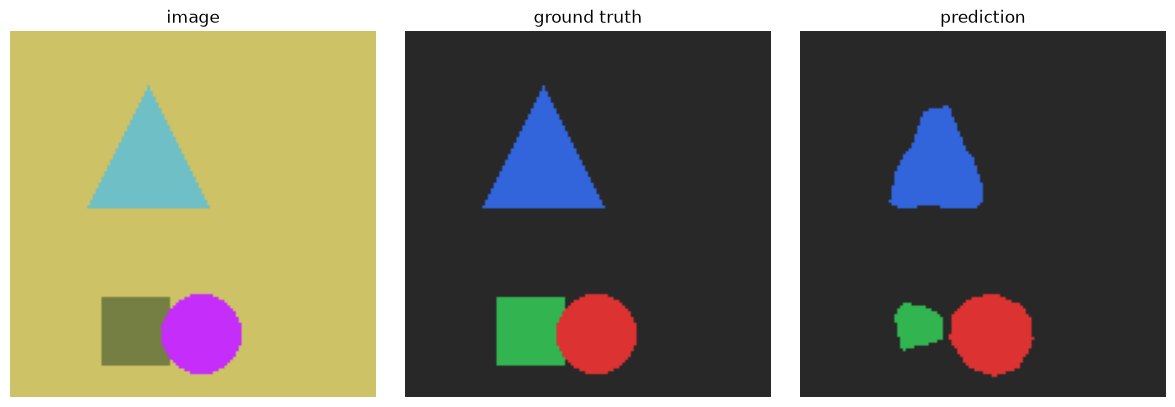

In [15]:
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models.segmentation import fcn_resnet50
from torchvision.models.segmentation.fcn import FCNHead

NUM_CLASSES = 4  # bg, circle, square, triangle
CLASS_NAMES = ["bg", "circle", "square", "triangle"]
CLASS_COLORS = np.array(
    [
        [40, 40, 40],      # bg
        [220, 50, 50],     # circle
        [50, 180, 80],     # square
        [50, 100, 220],    # triangle
    ],
    dtype=np.uint8,
)


class ShapeSegDataset(Dataset):
    """Random-colored shapes; label depends on geometry only."""

    def __init__(self, n=64, size=128, max_shapes=3, seed=0):
        self.n = n
        self.size = size
        self.max_shapes = max_shapes
        self.rng = random.Random(seed)

    def __len__(self):
        return self.n

    def _rand_rgb(self, avoid=None, min_delta=120):
        while True:
            c = (self.rng.randint(0, 255), self.rng.randint(0, 255), self.rng.randint(0, 255))
            if avoid is None or sum(abs(a - b) for a, b in zip(c, avoid)) >= min_delta:
                return c

    def __getitem__(self, idx):
        s = self.size
        bg = self._rand_rgb()
        img = Image.new("RGB", (s, s), bg)
        mask = Image.new("L", (s, s), 0)
        draw_img, draw_mask = ImageDraw.Draw(img), ImageDraw.Draw(mask)

        # always include all three shapes (order shuffled so overlaps vary)
        shape_ids = [1, 2, 3]
        self.rng.shuffle(shape_ids)
        for class_id in shape_ids:
            color = self._rand_rgb(avoid=bg)
            side = self.rng.randint(s // 6, s // 3)
            x0 = self.rng.randint(0, s - side)
            y0 = self.rng.randint(0, s - side)
            box = [x0, y0, x0 + side, y0 + side]
            if class_id == 1:  # circle
                draw_img.ellipse(box, fill=color)
                draw_mask.ellipse(box, fill=class_id)
            elif class_id == 2:  # square
                draw_img.rectangle(box, fill=color)
                draw_mask.rectangle(box, fill=class_id)
            else:  # triangle
                pts = [(x0, y0 + side), (x0 + side, y0 + side), (x0 + side // 2, y0)]
                draw_img.polygon(pts, fill=color)
                draw_mask.polygon(pts, fill=class_id)

        image = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.0
        target = torch.from_numpy(np.array(mask)).long()
        return image, target


def collate_fn(batch):
    images, targets = zip(*batch)
    return torch.stack(images, 0), torch.stack(targets, 0)


def build_shape_segmenter(num_classes=NUM_CLASSES):
    model = fcn_resnet50(weights="DEFAULT")
    # classifier in: 2048; aux in: 1024 (ResNet layer3)
    model.classifier = FCNHead(2048, num_classes)
    model.aux_classifier = FCNHead(1024, num_classes)
    for p in model.backbone.parameters():
        p.requires_grad = False
    for p in model.classifier.parameters():
        p.requires_grad = True
    for p in model.aux_classifier.parameters():
        p.requires_grad = True
    return model


def train_shape_segmenter(epochs=100, steps_per_epoch=12, batch_size=2, lr=1e-3):
    device = torch.device("mps")
    print("device:", device)
    ds = ShapeSegDataset(n=steps_per_epoch * batch_size, size=128, seed=0)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    model = build_shape_segmenter().to(device)
    opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)

    for epoch in range(epochs):
        model.train()
        model.backbone.eval()  # frozen BN stats
        total, n = 0.0, 0
        for images, targets in loader:
            images, targets = images.to(device), targets.to(device)
            out = model(images)
            loss_main, _ = combined_loss(out["out"], targets, NUM_CLASSES)
            loss_aux = F.cross_entropy(out["aux"], targets)
            loss = loss_main + 0.5 * loss_aux
            opt.zero_grad()
            loss.backward()
            opt.step()
            total += loss.item()
            n += 1
        print(f"epoch {epoch + 1}/{epochs}  loss={total / max(n, 1):.4f}")
    return model, device


def colorize_mask(mask_hw):
    return CLASS_COLORS[mask_hw.cpu().numpy()]


def show_shape_pred(model, device, score_seed=99):
    ds = ShapeSegDataset(n=1, size=128, seed=score_seed)
    image, target = ds[0]
    model.eval()
    with torch.no_grad():
        logits = model(image.unsqueeze(0).to(device))["out"][0]
    pred = logits.argmax(0)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(image.permute(1, 2, 0).numpy())
    axes[0].set_title("image")
    axes[1].imshow(colorize_mask(target))
    axes[1].set_title("ground truth")
    axes[2].imshow(colorize_mask(pred.cpu()))
    axes[2].set_title("prediction")
    for ax in axes:
        ax.axis("off")
    ious = iou_per_class(logits.unsqueeze(0), target.unsqueeze(0).to(device), NUM_CLASSES)
    msg = ", ".join(
        f"{n}={v:.2f}" if torch.isfinite(v) else f"{n}=nan"
        for n, v in zip(CLASS_NAMES, ious)
    )
    print("IoU:", msg)
    plt.tight_layout()
    plt.show()


model, device = train_shape_segmenter()
show_shape_pred(model, device)